In [1]:
"""
Trial-by-trial entropy (uncertainty U) mapped to reaction time (RT), per subject.

WHAT THIS DOES (high-level)
1) Loads:
   - trial-level behavioral data: all_data_online_07_02_24.csv  (has reward per dig, stay_num, etc.)
   - planet-level RT lists:       all_foraging_data_massive_be_07_02_24.csv (has rt_list per planet)
   - subject-level params:        all_foraging_data_07_02_24.csv (needs at least alpha + fileID)

2) Builds a trial-level RT dataframe by exploding rt_list into per-dig rows.

3) Computes a *deterministic* approximate CRP clustering posterior over “planet decay types”
   using a simple generative model on per-dig decay ratios:
        d_t = (r_{t-1} - r_t) / max(r_{t-1}, eps)
   Posterior over clusters => entropy U_t each dig.

4) Merges U_t with RT at matching (fileID, block, planet, true_planet, stay_num).

5) Saves a new CSV with columns:
   fileID, block, planet, true_planet, stay_num, reward, decay_ratio, U_entropy, galaxy, rt

NOTES / ASSUMPTIONS (important)
- This is NOT running the Julia simulator. It’s an inference-style approximation that avoids the
  “stochastic simulation length mismatch” problem you pointed out.
- We treat “planet type” as a CRP mixture over a latent mean decay-rate θ (per planet),
  and update cluster posteriors using conjugate Normal-Normal math on the fly.
- The only subject parameter used is alpha (CRP concentration). If you want gamma/beta/epsilon
  to shape U, we can extend later. For now U is purely posterior entropy over decay-type.
"""

import os
import ast
import numpy as np
import pandas as pd

# ---------- optional installs ----------
import sys, subprocess
def _install_if_missing(pkg):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

for _p in ["pandas","numpy"]:
    _install_if_missing(_p)

# ========== PATHS (edit if needed) ==========
TRIAL_PATH   = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\model\data\all_data_online_07_02_24.csv"
MASSIVE_PATH = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\semi_raw_data\all_foraging_data_massive_be_07_02_24.csv"
SUBJ_PATH    = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data\result_df\all_foraging_data_07_02_24.csv"

SAVE_DIR     = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new"
os.makedirs(SAVE_DIR, exist_ok=True)
OUT_CSV      = os.path.join(SAVE_DIR, "trial_entropy_U_mapped_to_RT.csv")

# ========== LOAD ==========
trial = pd.read_csv(TRIAL_PATH)
massive = pd.read_csv(MASSIVE_PATH)
subj = pd.read_csv(SUBJ_PATH)

for df in (trial, massive, subj):
    if "fileID" in df.columns:
        df["fileID"] = df["fileID"].astype(str).str.strip()

# ========== SANITY: required columns ==========
need_trial = ["fileID","block","planet_in_block","true_planet","stay_num","reward"]
miss_trial = [c for c in need_trial if c not in trial.columns]
if miss_trial:
    raise ValueError(f"TRIAL file missing columns: {miss_trial}")

need_massive = ["fileID","block","planet","true_planet","galaxy","rt_list"]
miss_massive = [c for c in need_massive if c not in massive.columns]
if miss_massive:
    raise ValueError(f"MASSIVE file missing columns: {miss_massive}")

# alpha: your CRP concentration parameter per subject
if "alpha" not in subj.columns:
    raise ValueError("SUBJ df must include 'alpha' (CRP concentration).")

# ========== 1) Build trial-level RT dataframe ==========
def parse_rt_list(x):
    if isinstance(x, str):
        x = x.strip()
        if x == "" or x.lower() == "nan":
            return None
        try:
            return ast.literal_eval(x)
        except Exception:
            return None
    if isinstance(x, list):
        return x
    return None

massive["rt_list_parsed"] = massive["rt_list"].apply(parse_rt_list)

rt_rows = []
for _, row in massive.iterrows():
    rts = row["rt_list_parsed"]
    if not isinstance(rts, list) or len(rts) == 0:
        continue

    # stay_num in your trial df starts at 0 for first dig; align rt index to stay_num
    for stay_num, rt in enumerate(rts):
        rt_rows.append({
            "fileID": row["fileID"],
            "block": row["block"],
            "planet": row["planet"],
            "true_planet": row["true_planet"],
            "galaxy": row["galaxy"],
            "stay_num": stay_num,
            "rt": rt
        })

rt_trial = pd.DataFrame(rt_rows)
# print(rt_trial.head())

# ========== 2) Prepare behavioral trial df keys aligned to massive ==========
# trial uses planet_in_block; massive uses planet
trial2 = trial.copy()
trial2 = trial2.rename(columns={"planet_in_block": "planet"})

# Keep only columns we need + any extras you want to carry through
trial2 = trial2[["fileID","block","planet","true_planet","stay_num","reward"]].copy()

# ========== 3) Compute decay ratio per dig (within planet) ==========
# Sort within planet by stay_num
trial2 = trial2.sort_values(["fileID","block","planet","true_planet","stay_num"]).reset_index(drop=True)

EPS = 1e-9

def add_decay_ratio(df_planet):
    # df_planet is one planet's sequence of digs
    r = df_planet["reward"].to_numpy(dtype=float)
    decay = np.full_like(r, np.nan, dtype=float)
    # decay at stay_num>=1
    for i in range(1, len(r)):
        denom = max(r[i-1], EPS)
        decay[i] = (r[i-1] - r[i]) / denom
    df_planet = df_planet.copy()
    df_planet["decay_ratio"] = decay
    return df_planet

trial2 = (
    trial2.groupby(["fileID","block","planet","true_planet"], group_keys=False)
    .apply(add_decay_ratio)
)

# ========== 4) CRP + conjugate Normal-Normal to get posterior cluster probs and entropy ==========
# We model a planet’s latent mean decay-rate θ; observed decay_ratio ~ Normal(θ, sigma_obs^2).
# Cluster k has prior θ ~ Normal(mu0, sigma0^2), and gets updated with all decay observations
# from planets assigned to that cluster (we assign each planet via MAP at planet end).

# ----- hyperparameters (reasonable defaults; tune if needed) -----
SIGMA_OBS = 0.25   # observation noise on decay_ratio (0..1-ish)
SIGMA0    = 0.50   # prior sd on θ
MU0       = 0.30   # prior mean decay (roughly a drop ratio)

def normal_logpdf(x, m, s):
    # stable scalar logpdf
    return -0.5*np.log(2*np.pi*s*s) - 0.5*((x-m)/s)**2

def entropy_from_probs(p):
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-(p * np.log(p)).sum()) if p.size else np.nan

class CRPClusters:
    """
    Maintain clusters with conjugate posterior over θ:
        θ | data ~ Normal(mu_k, var_k)
    using known SIGMA_OBS and prior Normal(MU0, SIGMA0^2).
    """
    def __init__(self, alpha):
        self.alpha = float(alpha) if np.isfinite(alpha) else 1.0
        self.counts = []     # n_k = number of planets assigned (not number of trials)
        self.mu = []         # posterior mean of θ
        self.var = []        # posterior var of θ

    def _prior_params(self):
        return MU0, SIGMA0**2

    def _predictive_loglik_single(self, x, mu_k, var_k):
        # predictive for x marginalizing θ:
        # x ~ Normal(mu_k, SIGMA_OBS^2 + var_k)
        s2 = SIGMA_OBS**2 + var_k
        return normal_logpdf(x, mu_k, np.sqrt(s2))

    def cluster_logprior(self):
        # CRP prior over existing clusters + new cluster:
        # p(k) ∝ n_k, p(new) ∝ alpha
        n = np.array(self.counts, dtype=float)
        total = n.sum() + self.alpha
        if total <= 0:
            # no clusters yet
            return np.array([0.0])  # only "new"
        lp_exist = np.log(np.maximum(n, 1e-12)) - np.log(total)
        lp_new = np.log(self.alpha) - np.log(total)
        return np.concatenate([lp_exist, [lp_new]])

    def _new_cluster_posterior_from_obs(self, obs):
        # posterior on θ given obs (array) under Normal prior and Normal likelihood
        # prior: N(MU0, SIGMA0^2)
        mu0, v0 = self._prior_params()
        if len(obs) == 0:
            return mu0, v0

        obs = np.asarray(obs, dtype=float)
        obs = obs[np.isfinite(obs)]
        if obs.size == 0:
            return mu0, v0

        # precision form:
        prec0 = 1.0 / v0
        prec = prec0 + obs.size / (SIGMA_OBS**2)
        v_post = 1.0 / prec
        m_post = v_post * (prec0 * mu0 + obs.sum() / (SIGMA_OBS**2))
        return m_post, v_post

    def posterior_cluster_probs(self, obs_so_far):
        """
        obs_so_far: list/array of observed decay_ratio within current planet up to current dig.
        Returns probs over [existing clusters..., new_cluster]
        """
        lp = self.cluster_logprior()  # len K+1
        obs = np.asarray(obs_so_far, dtype=float)
        obs = obs[np.isfinite(obs)]
        # if no obs yet, posterior is just prior
        if obs.size == 0:
            # normalize
            m = np.max(lp)
            p = np.exp(lp - m)
            p /= p.sum()
            return p

        # add likelihood of obs under each existing cluster
        lls = []
        for k in range(len(self.counts)):
            ll = 0.0
            for x in obs:
                ll += self._predictive_loglik_single(x, self.mu[k], self.var[k])
            lls.append(ll)

        # likelihood under "new" cluster: integrate with prior (i.e., predictive using prior)
        mu0, v0 = self._prior_params()
        ll_new = 0.0
        for x in obs:
            ll_new += self._predictive_loglik_single(x, mu0, v0)

        lls = np.array(lls + [ll_new], dtype=float)
        lp_post = lp + lls

        # normalize safely
        m = np.max(lp_post)
        p = np.exp(lp_post - m)
        p /= p.sum()
        return p

    def assign_planet_and_update(self, obs_full):
        """
        At planet end, assign to MAP cluster (existing or new) using all obs,
        then update that cluster posterior and planet counts.
        """
        p = self.posterior_cluster_probs(obs_full)
        k_map = int(np.argmax(p))  # 0..K for new
        # compute posterior params for θ given obs_full
        m_post, v_post = self._new_cluster_posterior_from_obs(obs_full)

        if k_map == len(self.counts):
            # new cluster
            self.counts.append(1)
            self.mu.append(m_post)
            self.var.append(v_post)
        else:
            # existing: update cluster posterior by combining its prior (current posterior) with new obs
            # Treat current cluster posterior as "prior" for θ, then update with obs_full
            mu_prior = self.mu[k_map]
            v_prior  = self.var[k_map]

            obs = np.asarray(obs_full, dtype=float)
            obs = obs[np.isfinite(obs)]
            if obs.size > 0:
                prec0 = 1.0 / v_prior
                prec = prec0 + obs.size / (SIGMA_OBS**2)
                v_new = 1.0 / prec
                m_new = v_new * (prec0 * mu_prior + obs.sum() / (SIGMA_OBS**2))
                self.mu[k_map] = m_new
                self.var[k_map] = v_new

            self.counts[k_map] += 1

        return k_map, p

# ========== 5) Compute U entropy per dig, per subject ==========
# Attach alpha per subject
alpha_map = subj.set_index("fileID")["alpha"].to_dict()

trial2["U_entropy"] = np.nan

# Process each subject sequentially across planets in time order
group_cols = ["fileID"]
planet_cols = ["fileID","block","planet","true_planet"]

# For time order, we assume block then planet then (within planet) stay_num
trial2 = trial2.sort_values(["fileID","block","planet","true_planet","stay_num"]).reset_index(drop=True)

for fid, df_sub in trial2.groupby("fileID", sort=False):
    alpha = alpha_map.get(fid, np.nan)
    if not np.isfinite(alpha):
        alpha = 1.0

    crp = CRPClusters(alpha=alpha)

    # iterate planets
    for (fid2, b, p, tp), df_plan in df_sub.groupby(planet_cols, sort=False):
        # df_plan already sorted by stay_num
        obs = []
        idxs = df_plan.index.to_numpy()

        # For each dig, compute posterior over clusters given obs so far => entropy
        # (skip NaN decay at first dig)
        for j, ix in enumerate(idxs):
            d = df_plan.loc[ix, "decay_ratio"]
            if np.isfinite(d):
                obs.append(float(d))

            probs = crp.posterior_cluster_probs(obs)
            trial2.loc[ix, "U_entropy"] = entropy_from_probs(probs)

        # at planet end: assign + update clusters
        crp.assign_planet_and_update(obs_full=obs)

print("✅ Computed U_entropy for trial2.")

# ========== 6) Merge with trial-level RT ==========
merged = trial2.merge(
    rt_trial,
    on=["fileID","block","planet","true_planet","stay_num"],
    how="left",
    validate="one_to_one"
)

# Keep galaxy if present from RT side; if you want, also merge galaxy from trial-level file (if exists)
# Here we keep it as provided by massive (rt_trial).
cols_out = [
    "fileID","block","planet","true_planet","stay_num",
    "reward","decay_ratio","U_entropy","galaxy","rt"
]
merged_out = merged[cols_out].copy()

# ========== 7) Save ==========
merged_out.to_csv(OUT_CSV, index=False)
print(f"✅ Saved: {OUT_CSV}")
print("Output shape:", merged_out.shape)
print(merged_out.head())


C:\Users\zyfxl\AppData\Local\Temp\ipykernel_95660\2083889300.py:145: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(add_decay_ratio)


✅ Computed U_entropy for trial2.
✅ Saved: C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\trial_entropy_U_mapped_to_RT.csv
Output shape: (78889, 10)
     fileID  block  planet  true_planet  stay_num  reward  decay_ratio  \
0  01yo7fr5      1       0            0         0    91.0          NaN   
1  01yo7fr5      1       0            0         1    27.0     0.703297   
2  01yo7fr5      1       0            0         2     3.0     0.888889   
3  01yo7fr5      1       0            0         3     1.0     0.666667   
4  01yo7fr5      1       1            1         0    97.0          NaN   

   U_entropy  galaxy     rt  
0  -0.000000     0.0  473.7  
1  -0.000000     0.0  299.8  
2  -0.000000     0.0  442.2  
3  -0.000000     0.0  205.8  
4   0.571298     0.0  183.0  


In [7]:
import pandas as pd

# ============================================================
# Paths
# ============================================================
entropy_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\trial_entropy_U_mapped_to_RT.csv"

full_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\model\data\all_data_online_07_02_24.csv"

# ============================================================
# Load
# ============================================================
entropy_df = pd.read_csv(entropy_path)
full_df = pd.read_csv(full_path)

print("entropy_df columns:")
print(entropy_df.columns.tolist())

print("\nfull_df columns:")
print(full_df.columns.tolist())

# ============================================================
# Use only keys that actually exist in BOTH files
# ============================================================
candidate_keys = ["fileID", "block_num", "planet_num", "stay_num"]
merge_keys = [c for c in candidate_keys if c in entropy_df.columns and c in full_df.columns]

print("\nUsing merge keys:", merge_keys)

if "galaxy" not in full_df.columns:
    raise ValueError("Column 'galaxy' not found in full_df")

if len(merge_keys) == 0:
    raise ValueError("No shared merge keys found between the two files.")

# ============================================================
# Remove old galaxy in entropy_df if it exists
# ============================================================
if "galaxy" in entropy_df.columns:
    entropy_df = entropy_df.drop(columns=["galaxy"])

# ============================================================
# Keep only needed columns and deduplicate
# ============================================================
galaxy_df = full_df[merge_keys + ["galaxy"]].copy()
galaxy_df = galaxy_df.drop_duplicates()

# ============================================================
# Merge
# ============================================================
merged_df = entropy_df.merge(
    galaxy_df,
    on=merge_keys,
    how="left"
)

# ============================================================
# Diagnostics
# ============================================================
print("\nFraction missing galaxy after merge:",
      merged_df["galaxy"].isna().mean())

print("Unique galaxy values after merge:",
      merged_df["galaxy"].dropna().unique())

# Optional: inspect unmatched rows
unmatched = merged_df[merged_df["galaxy"].isna()]
print("Number of unmatched rows:", len(unmatched))
if len(unmatched) > 0:
    print("\nSample unmatched rows:")
    cols_to_show = [c for c in merge_keys if c in unmatched.columns]
    print(unmatched[cols_to_show].head(10))

# ============================================================
# Save
# ============================================================
save_path = entropy_path.replace(".csv", "_with_galaxy.csv")
merged_df.to_csv(save_path, index=False)

print("\nSaved updated file ->", save_path)

entropy_df columns:
['fileID', 'block', 'planet', 'true_planet', 'stay_num', 'reward', 'decay_ratio', 'U_entropy', 'galaxy', 'rt']

full_df columns:
['fileID', 'sub_num', 'block', 'true_planet', 'planet_num', 'galaxy', 'stay_num', 'reward', 'planet_in_block']

Using merge keys: ['fileID', 'stay_num']

Fraction missing galaxy after merge: 0.0
Unique galaxy values after merge: [0 1 2]
Number of unmatched rows: 0

Saved updated file -> C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\trial_entropy_U_mapped_to_RT_with_galaxy.csv


## Assume The Above Code has Been Run, and the csv file exists, We now make plots of U vs RT

Loaded rows: 33472
Unique subjects: 297
Galaxy values: [np.int64(0), np.int64(1), np.int64(2)]

Rows in subject x galaxy correlation table: 890
Unique subjects retained: 297

Counts per galaxy:
galaxy
0    296
1    297
2    297
Name: count, dtype: int64

How many galaxy-correlations per subject?
galaxy
2      1
3    296
Name: count, dtype: int64

Subjects with all 3 galaxy correlations: 296 / 297

=== Group statistics by galaxy ===
Galaxy 0: n=296, mean rho=-0.018 ± 0.244, t=-1.26, p=0.2073
Galaxy 1: n=297, mean rho=-0.001 ± 0.226, t=-0.09, p=0.9253
Galaxy 2: n=297, mean rho=0.029 ± 0.217, t=2.28, p=0.02356


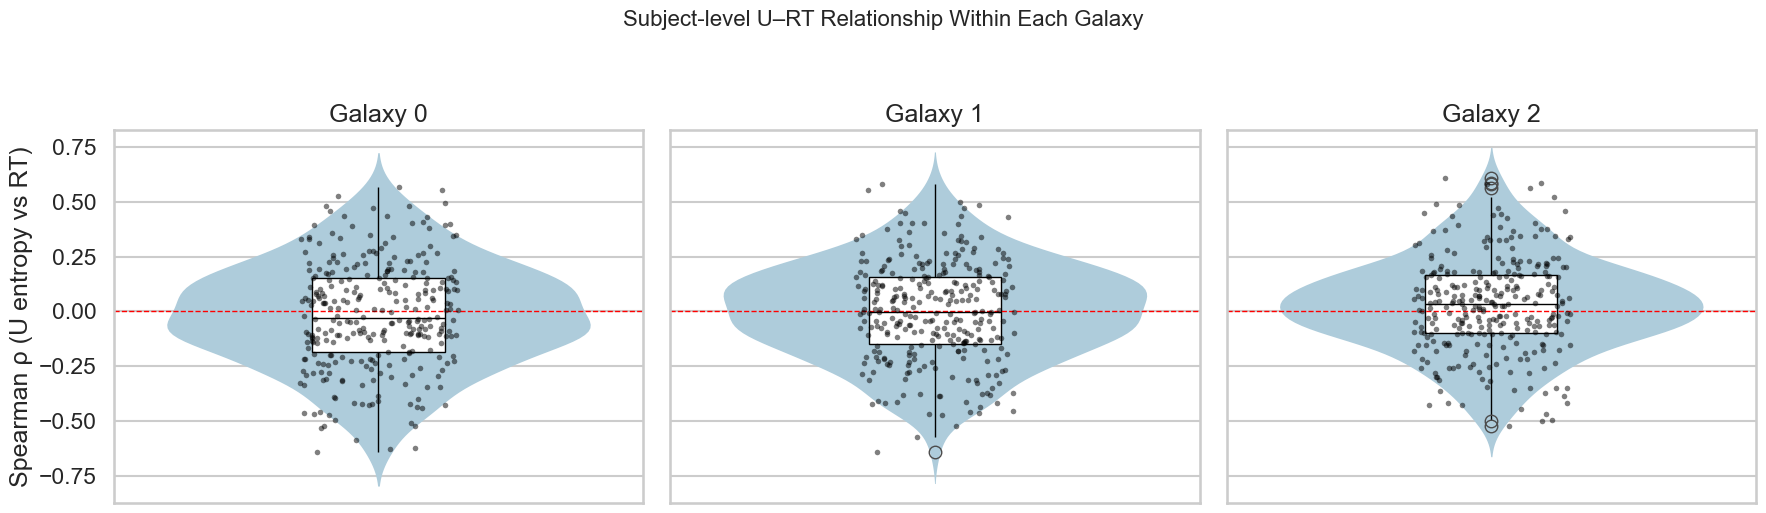


Saved galaxy-wise plot → C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\U_vs_RT_subject_distribution_by_galaxy.png
Saved subject x galaxy correlation table → C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\subject_by_galaxy_U_RT_correlations.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, ttest_1samp

# ============================================================
# 1. Load entropy–RT mapping
# ============================================================
csv_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\trial_entropy_U_mapped_to_RT_with_galaxy.csv"
df = pd.read_csv(csv_path)

# Basic cleanup
df = df.dropna(subset=["fileID", "U_entropy", "rt", "galaxy"])
df = df[df["rt"] > 50]          # optional RT sanity filter
df = df[df["U_entropy"] > 0]

# Force galaxy to integer if possible
df["galaxy"] = pd.to_numeric(df["galaxy"], errors="coerce")
df = df.dropna(subset=["galaxy"])
df["galaxy"] = df["galaxy"].astype(int)

print("Loaded rows:", len(df))
print("Unique subjects:", df["fileID"].nunique())
print("Galaxy values:", sorted(df["galaxy"].unique()))

# ============================================================
# 2. Compute subject x galaxy correlations

min_trials_per_galaxy = 15

rows = []

for (fid, galaxy_val), sub in df.groupby(["fileID", "galaxy"]):
    n = len(sub)

    if n < min_trials_per_galaxy:
        continue

    # Spearman correlation within this subject and this galaxy
    r, p = spearmanr(sub["U_entropy"], sub["rt"])

    # guard against degenerate cases
    if pd.isna(r):
        continue

    rows.append({
        "fileID": fid,
        "galaxy": galaxy_val,
        "rho_U_RT": r,
        "p_value": p,
        "n_trials": n
    })

corr_df = pd.DataFrame(rows)

print("\nRows in subject x galaxy correlation table:", len(corr_df))
print("Unique subjects retained:", corr_df["fileID"].nunique())
print("\nCounts per galaxy:")
print(corr_df["galaxy"].value_counts().sort_index())

print("\nHow many galaxy-correlations per subject?")
print(corr_df.groupby("fileID")["galaxy"].nunique().value_counts().sort_index())

# Optional: inspect whether most subjects contributed all 3 galaxies
subject_counts = corr_df.groupby("fileID")["galaxy"].nunique()
n_all3 = (subject_counts == 3).sum()
print(f"\nSubjects with all 3 galaxy correlations: {n_all3} / {len(subject_counts)}")

# ============================================================
# 3. Group-level stats separately for each galaxy
# ============================================================
print("\n=== Group statistics by galaxy ===")
galaxy_stats = []

for galaxy_val in sorted(corr_df["galaxy"].unique()):
    subdf = corr_df[corr_df["galaxy"] == galaxy_val].copy()

    mean_rho = subdf["rho_U_RT"].mean()
    std_rho  = subdf["rho_U_RT"].std()

    if len(subdf) > 1:
        tval, pval = ttest_1samp(subdf["rho_U_RT"], 0)
    else:
        tval, pval = np.nan, np.nan

    galaxy_stats.append({
        "galaxy": galaxy_val,
        "n_subjects": len(subdf),
        "mean_rho": mean_rho,
        "std_rho": std_rho,
        "tval": tval,
        "pval": pval
    })

    print(f"Galaxy {galaxy_val}: n={len(subdf)}, mean rho={mean_rho:.3f} ± {std_rho:.3f}, t={tval:.2f}, p={pval:.4g}")

galaxy_stats_df = pd.DataFrame(galaxy_stats)

# ============================================================
# 4. Publication-style 1x3 plot by galaxy
# ============================================================
sns.set(style="whitegrid", context="talk")

galaxy_order = sorted(corr_df["galaxy"].unique())

# Optional labels
galaxy_name_map = {
    0: "Galaxy 0",
    1: "Galaxy 1",
    2: "Galaxy 2"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, galaxy_val in enumerate(galaxy_order):
    ax = axes[i]
    subdf = corr_df[corr_df["galaxy"] == galaxy_val].copy()

    if len(subdf) == 0:
        ax.set_title(f"{galaxy_name_map.get(galaxy_val, f'Galaxy {galaxy_val}')}\nNo data")
        ax.axis("off")
        continue

    mean_rho = subdf["rho_U_RT"].mean()

    if len(subdf) > 1:
        tval, pval = ttest_1samp(subdf["rho_U_RT"], 0)
    else:
        tval, pval = np.nan, np.nan

    sns.violinplot(
        y=subdf["rho_U_RT"],
        inner=None,
        color="#A6CEE3",
        linewidth=0,
        ax=ax
    )

    sns.boxplot(
        y=subdf["rho_U_RT"],
        width=0.25,
        showcaps=False,
        boxprops=dict(facecolor="white", edgecolor="black"),
        whiskerprops=dict(color="black"),
        medianprops=dict(color="black"),
        ax=ax
    )

    sns.stripplot(
        y=subdf["rho_U_RT"],
        color="black",
        alpha=0.5,
        size=4,
        jitter=0.15,
        ax=ax
    )

    ax.axhline(0, color="red", linestyle="--", linewidth=1)

    # ax.text(
    #     0.03, 0.97,
    #     f"n = {len(subdf)}\n"
    #     f"Mean ρ = {mean_rho:.3f}\n"
    #     f"t = {tval:.2f}, p = {pval:.3g}",
    #     transform=ax.transAxes,
    #     ha="left", va="top",
    #     fontsize=11
    # )

    ax.set_title(galaxy_name_map.get(galaxy_val, f"Galaxy {galaxy_val}"))
    ax.set_xlabel("")

    if i == 0:
        ax.set_ylabel("Spearman ρ (U entropy vs RT)")
    else:
        ax.set_ylabel("")

    # # subplot labels A, B, C
    # ax.text(
    #     -0.18, 1.05, chr(65 + i),
    #     transform=ax.transAxes,
    #     fontsize=18,
    #     fontweight="bold",
    #     va="top", ha="left"
    # )

fig.suptitle("Subject-level U–RT Relationship Within Each Galaxy", y=1.04, fontsize=16)
plt.tight_layout()

save_path_galaxy = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\U_vs_RT_subject_distribution_by_galaxy.png"
plt.savefig(save_path_galaxy, dpi=600, bbox_inches="tight")
plt.show()

print("\nSaved galaxy-wise plot →", save_path_galaxy)

# ============================================================
# 5. Save the subject x galaxy correlation table
# ============================================================
corr_save_path = r"C:\Users\zyfxl\OneDrive - UC Irvine\UCI\CCNL Lab\Foraging Task Overview\foraging_MQLP-main\foraging_MQLP-main\data_analysis_new\subject_by_galaxy_U_RT_correlations.csv"
corr_df.to_csv(corr_save_path, index=False)

print("Saved subject x galaxy correlation table →", corr_save_path)